# Diamon Price Prediction with Machine Learning

<img src='https://www.rodanjewellers.ca/wp-content/plugins/phastpress/phast.php?service=images&src=https%3A%2F%2Fwww.rodanjewellers.ca%2Fwp-content%2Fuploads%2F2025%2F03%2Fdiamond-with-high-quality-transparent-background-scaled.jpg&cacheMarker=1742671100-310236&token=4b6153befaeb9e1d'>

🇹🇷 Türkçe
Bu projenin amacı, çeşitli makine öğrenmesi ve derin öğrenme algoritmalarını kullanarak elmas fiyatlarını tahmin etmektir.

🇬🇧 English
The aim of this project is to predict diamond prices using various machine learning and deep learning algorithms.

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense

In [2]:
df=pd.read_csv('diamonds.csv') 

In [3]:
#EDA

In [4]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
df.tail()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,53940,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [7]:
df.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [8]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


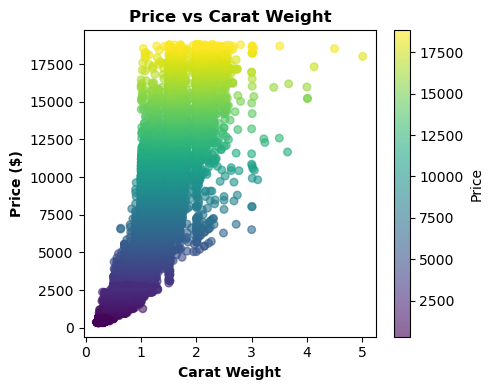

In [9]:
# Price vs Carat
plt.figure(figsize=(5, 4))
plt.scatter(df['carat'], df['price'], c=df['price'], cmap='viridis', alpha=0.6, s=30)
plt.xlabel('Carat Weight', fontweight='bold')
plt.ylabel('Price ($)', fontweight='bold')
plt.title('Price vs Carat Weight', fontweight='bold')
plt.colorbar(label='Price')
plt.tight_layout()
plt.show()

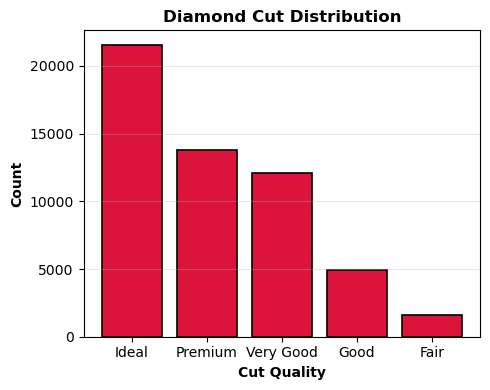

In [10]:
# Cut Quality Distribution
plt.figure(figsize=(5, 4))
cut_counts = df['cut'].value_counts().sort_values(ascending=False)
plt.bar(cut_counts.index, cut_counts.values, color='#DC143C', edgecolor='black', linewidth=1.2)
plt.xlabel('Cut Quality', fontweight='bold')
plt.ylabel('Count', fontweight='bold')
plt.title('Diamond Cut Distribution', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

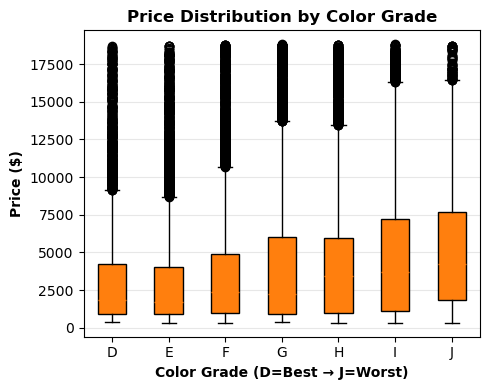

In [11]:
# Price by Color Grade
plt.figure(figsize=(5, 4))
color_order = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
box_data = [df[df['color'] == c]['price'].values for c in color_order if c in df['color'].unique()]
bp = plt.boxplot(box_data, labels=[c for c in color_order if c in df['color'].unique()], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#ff7f0e')
plt.xlabel('Color Grade (D=Best → J=Worst)', fontweight='bold')
plt.ylabel('Price ($)', fontweight='bold')
plt.title('Price Distribution by Color Grade', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

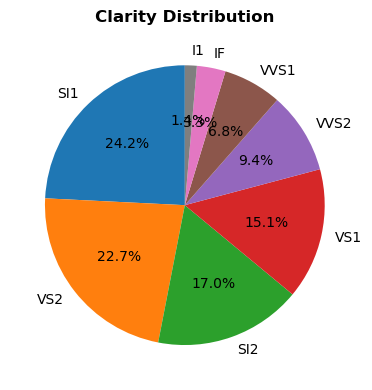

In [12]:
# Clarity Distribution
plt.figure(figsize=(6, 4))
clarity_counts = df['clarity'].value_counts()
plt.pie(clarity_counts.values, labels=clarity_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Clarity Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

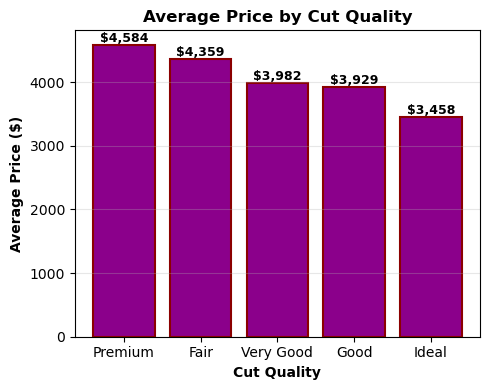

In [13]:
# Average Price by Cut Quality
plt.figure(figsize=(5, 4))
avg_price_cut = df.groupby('cut')['price'].mean().sort_values(ascending=False)
bars = plt.bar(avg_price_cut.index, avg_price_cut.values, color='#8B008B', edgecolor='darkred', linewidth=1.5)
plt.xlabel('Cut Quality', fontweight='bold')
plt.ylabel('Average Price ($)', fontweight='bold')
plt.title('Average Price by Cut Quality', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'${height:,.0f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

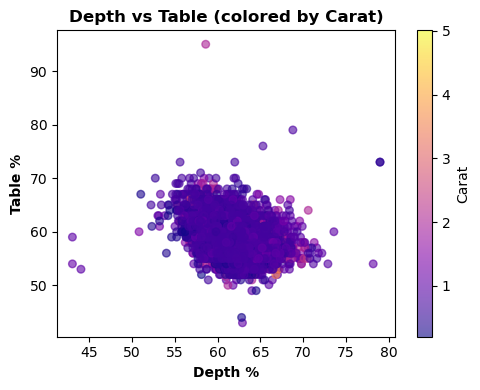

In [14]:
# Depth vs Table
plt.figure(figsize=(5, 4))
plt.scatter(df['depth'], df['table'], c=df['carat'], cmap='plasma', alpha=0.6, s=30)
plt.xlabel('Depth %', fontweight='bold')
plt.ylabel('Table %', fontweight='bold')
plt.title('Depth vs Table (colored by Carat)', fontweight='bold')
plt.colorbar(label='Carat')
plt.tight_layout()
plt.show()

In [15]:
#Feature Engineering

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [17]:
df.cut.value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

In [18]:
df.color.value_counts()

color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

In [19]:
df.clarity.value_counts()

clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64

In [20]:
# Categorical to Numerical Cut, Color, Clarity
cut_mapping = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}
color_mapping = {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7}
clarity_mapping = {'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4, 'VS1': 5, 'VVS2': 6, 'VVS1': 7, 'IF': 8}

df['cut'] = df['cut'].map(cut_mapping)
df['color'] = df['color'].map(color_mapping)
df['clarity'] = df['clarity'].map(clarity_mapping)

In [21]:
# Quality Score
df['quality_score'] = (df['cut'] + df['color'] + df['clarity']) / 3

In [22]:
df.describe()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z,quality_score
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,3.904097,4.405803,4.051020,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734,4.120307
std,15571.281097,0.474011,1.116600,1.701105,1.647136,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699,0.911883
min,1.000000,0.200000,1.000000,1.000000,1.000000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000,1.000000
25%,13485.750000,0.400000,3.000000,3.000000,3.000000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000,3.333333
50%,26970.500000,0.700000,4.000000,4.000000,4.000000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000,4.000000
75%,40455.250000,1.040000,5.000000,6.000000,5.000000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000,4.666667
max,53940.000000,5.010000,5.000000,7.000000,8.000000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000,6.666667


In [23]:
df = df.drop('Unnamed: 0', axis=1)

In [24]:
# Size Features (x, y, z dimensions)
df['volume'] = df['x'] * df['y'] * df['z']

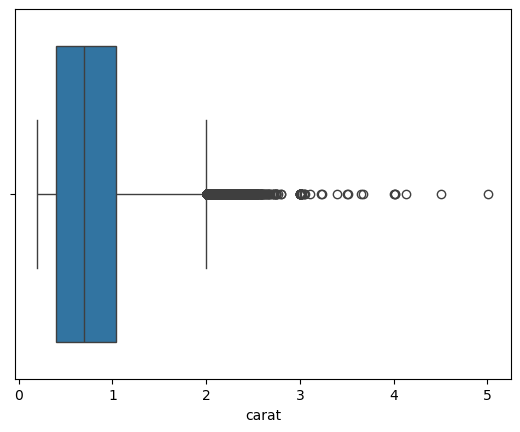

In [25]:
sns.boxplot(x=df['carat']);  

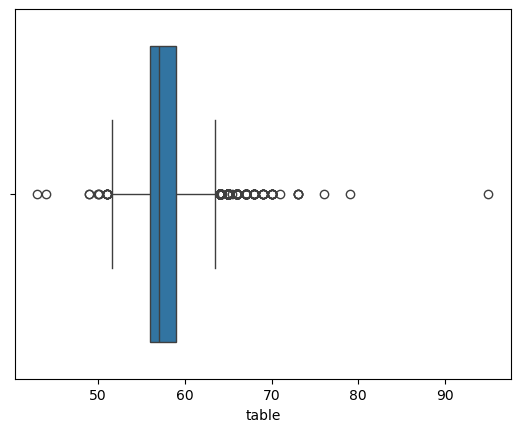

In [26]:
sns.boxplot(x=df['table']);  

In [27]:
df['carat'].mean()+3*df['carat'].std()
df['table'].mean()+3*df['table'].std()

np.float64(64.16065559650879)

In [28]:
#Correlation by Salary
abs(df.corr(numeric_only=True))['price'].sort_values(ascending=False) 

price            1.000000
carat            0.921591
volume           0.902385
x                0.884435
y                0.865421
z                0.861249
quality_score    0.217494
color            0.172511
clarity          0.146800
table            0.127134
cut              0.053491
depth            0.010647
Name: price, dtype: float64

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   carat          53940 non-null  float64
 1   cut            53940 non-null  int64  
 2   color          53940 non-null  int64  
 3   clarity        53940 non-null  int64  
 4   depth          53940 non-null  float64
 5   table          53940 non-null  float64
 6   price          53940 non-null  int64  
 7   x              53940 non-null  float64
 8   y              53940 non-null  float64
 9   z              53940 non-null  float64
 10  quality_score  53940 non-null  float64
 11  volume         53940 non-null  float64
dtypes: float64(8), int64(4)
memory usage: 4.9 MB


In [30]:
x= df.drop(['cut', 'depth', 'clarity', 'price'], axis=1)

y=df[['price']]

In [31]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test=train_test_split(x,y, random_state=42, test_size=0.20)

In [32]:
lr=LinearRegression()

In [33]:
model=lr.fit(x_train, y_train)

In [34]:
tahmin=lr.predict(x_test)

In [35]:
r2_score(y_test,tahmin)

0.9003622342514475

In [36]:
mean_squared_error(y_test,tahmin)**0.5

1258.540333842015

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
       
        
        algos=[L,R,Lass,E,ETR,GBR,kn,dt,xgb]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','Extra Tree','Gradient Boosting','KNeighborsRegressor','Decision Tree','XGBRegressor']
        
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.2,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [38]:
algo_test(x,y)

,R_Squared,RMSE,MAE
XGBRegressor,0.970186,688.439517,353.091827
Gradient Boosting,0.961728,780.000285,420.794236
KNeighborsRegressor,0.941103,967.614480,502.572822
Decision Tree,0.940377,973.556507,474.990638
Extra Tree,0.937510,996.686813,488.750834
Lasso,0.900404,1258.278266,822.015901
Ridge,0.900373,1258.469296,821.223106
Linear,0.900362,1258.540334,821.149556
ElasticNet,0.882559,1366.359336,873.077076


In [39]:
comparison = pd.DataFrame({
    'Actual': y_test.values.ravel(),
    'Predicted': tahmin.ravel()
})

comparison.head(10)

,Actual,Predicted
0,559,954.903343
1,2201,2449.868466
2,1238,2149.659733
3,1304,2021.320103
4,6901,10538.183589
5,3011,4065.448320
6,1765,2247.078877
7,1679,2615.447471
8,2102,2755.237303
9,4789,6228.948295


In [40]:
residuals=y_test-tahmin

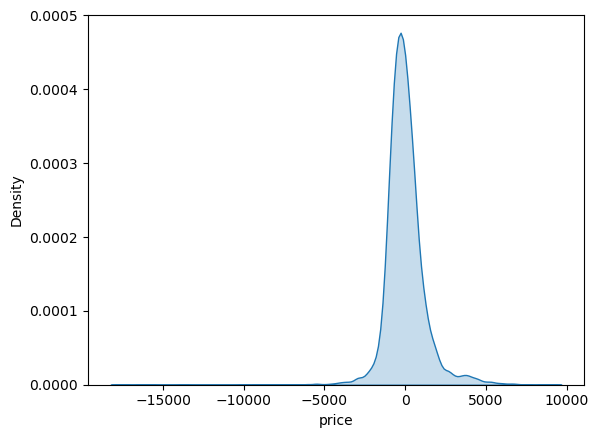

In [41]:
sns.kdeplot(x=residuals['price'], fill=True); 

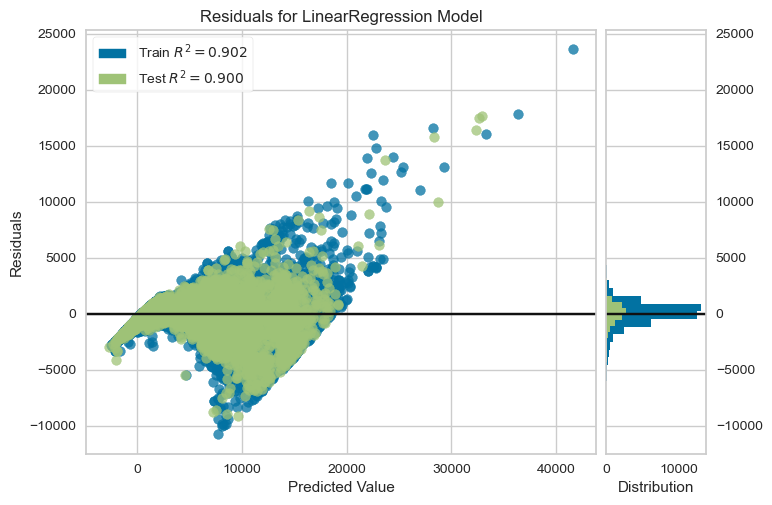

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [42]:
from yellowbrick.regressor import ResidualsPlot
vis = ResidualsPlot(model, force_model=True)
vis.fit(x_train, y_train)
vis.score(x_test, y_test)
vis.show()

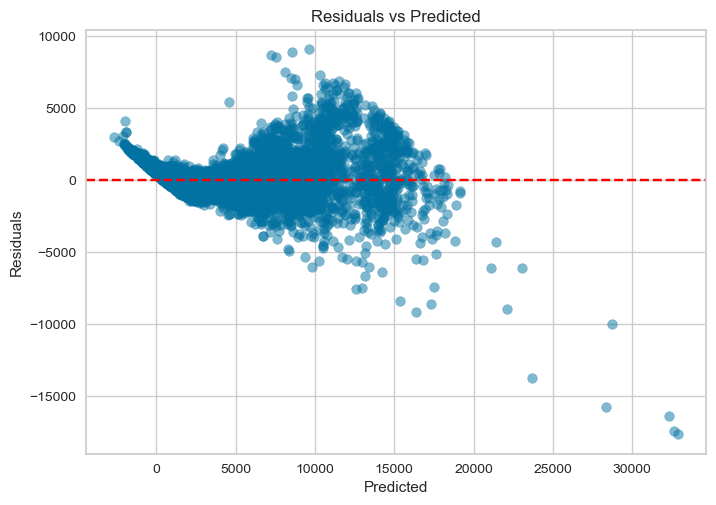

In [43]:
#ya da;
y_pred = model.predict(x_test)
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

In [ ]:
# ============================================================
# PICKLE FORMATINDA KAYDET
# ============================================================

# Bundle oluştur (model + scaler)
bundle = {
    'model': model,
    'scaler': None
}

# Pickle formatında kaydet
with open('diamond_bundle.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print("\n✓ diamond_bundle.pkl kaydedildi")

# ============================================================
# JOBLIB FORMATINDA KAYDET
# ============================================================

# Doğrudan model'i joblib ile kaydet
joblib.dump(model, 'diamond_model.joblib')

print("✓ diamond_model.joblib kaydedildi")

In [55]:
# with DEEP LEarnıng

In [44]:
x= df.drop(['cut', 'depth', 'clarity', 'price'], axis=1)

y=df[['price']]

In [46]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   carat          53940 non-null  float64
 1   color          53940 non-null  int64  
 2   table          53940 non-null  float64
 3   x              53940 non-null  float64
 4   y              53940 non-null  float64
 5   z              53940 non-null  float64
 6   quality_score  53940 non-null  float64
 7   volume         53940 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 3.3 MB


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x=scaler.fit_transform(x)

In [50]:
model=Sequential()
model.add(Dense(80, activation='relu'))           
model.add(Dense(120, activation='relu'))  
model.add(Dense(64, activation='relu'))  
model.add(Dense(30, activation='relu'))  
model.add(Dense(8, activation='relu'))  
model.add(Dense(1))  #sigmoid yok  classificaton binary idi. 

model.compile(loss='mean_squared_error', optimizer='adam')

In [51]:
early_stop=EarlyStopping(monitor='val_loss',patience=20)

In [52]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50,batch_size=64,callbacks=[early_stop],verbose=1)

Epoch 1/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 4901028.5000 - val_loss: 1981554.8750
Epoch 2/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2782794.5000 - val_loss: 1727250.3750
Epoch 3/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2523486.5000 - val_loss: 1454051.1250
Epoch 4/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2128244.7500 - val_loss: 1335552.1250
Epoch 5/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1901686.2500 - val_loss: 1216365.3750
Epoch 6/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1562852.7500 - val_loss: 1193531.3750
Epoch 7/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1259274.6250 - val_loss: 1053020.5000
Epoch 8/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1115991.3750 - val_loss: 983428.4375
Epoch 9/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1024112.9375 - val_loss: 931245.3125
Epoch 10/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 981183.0625 - val_loss: 962937.1875
Epoch 11/50
675/675 ━━━

In [53]:
tahmin = model.predict(x_test).flatten()

print("R2:", r2_score(y_test, tahmin))
print("RMSE:", np.sqrt(mean_squared_error(y_test, tahmin)))

338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
R2: 0.9566810727119446
RMSE: 829.8394046440552


In [56]:
comparison = pd.DataFrame({
    "Gerçek Fiyat": y_test.to_numpy().ravel(),
    "Tahmin Fiyat": tahmin.ravel()
})

comparison.head(10)

,Gerçek Fiyat,Tahmin Fiyat
0,559,602.177734
1,2201,2092.634033
2,1238,1151.823975
3,1304,1246.734619
4,6901,11314.486328
5,3011,3943.765381
6,1765,1856.963623
7,1679,1756.491089
8,2102,2219.216064
9,4789,5814.651367


In [58]:
model.save('diamond_price.h5')

🇹🇷 Türkçe
Bu çalışmada, elmas fiyatlarını tahmin etmek amacıyla farklı makine öğrenmesi regresyon modelleri ve deep learning algoritması kullanılmıştır. Veri ön işleme ve modelleme süreçlerinin ardından modeller performans metrikleri ile karşılaştırılmıştır. Sonuçlara göre XGBRegressor modeli en yüksek başarıyı (R² ≈ 0.97) elde ederek en düşük hata oranlarıyla en iyi tahmin performansını göstermiştir. Deep leraning ile %95 oranında başarı elde edilmiştir. 

🇬🇧 English
In this study, different machine learning regression models and a deep learning algorithm were used to predict diamond prices. After data preprocessing and modeling, the models were compared using performance metrics. According to the results, the XGBRegressor model achieved the highest success rate (R² ≈ 0.97), demonstrating the best prediction performance with the lowest error rates. Deep learning achieved a 95% success rate.